In [ ]:
from astropy.table import Table 
import numpy as np
import matplotlib.pyplot as plt
# load data onto an astropy table

jades_path = '/home/caltech-msanche3/data/JADES_north_fits_data.fits'
jades_data = Table.read(jades_path, hdu='KRON_CONV',format='fits')
# change units of flux from nJy to microJy so eazy fits correctly
for col in jades_data.colnames:
    if '_KRON' in col or '_ei' in col:
        jades_data[col] = jades_data[col] * 0.001
redshift = Table.read(jades_path, hdu='PHOTOZ_KRON',format='fits')
# 20615 and 11262 are from Kasper paper



24 24 24


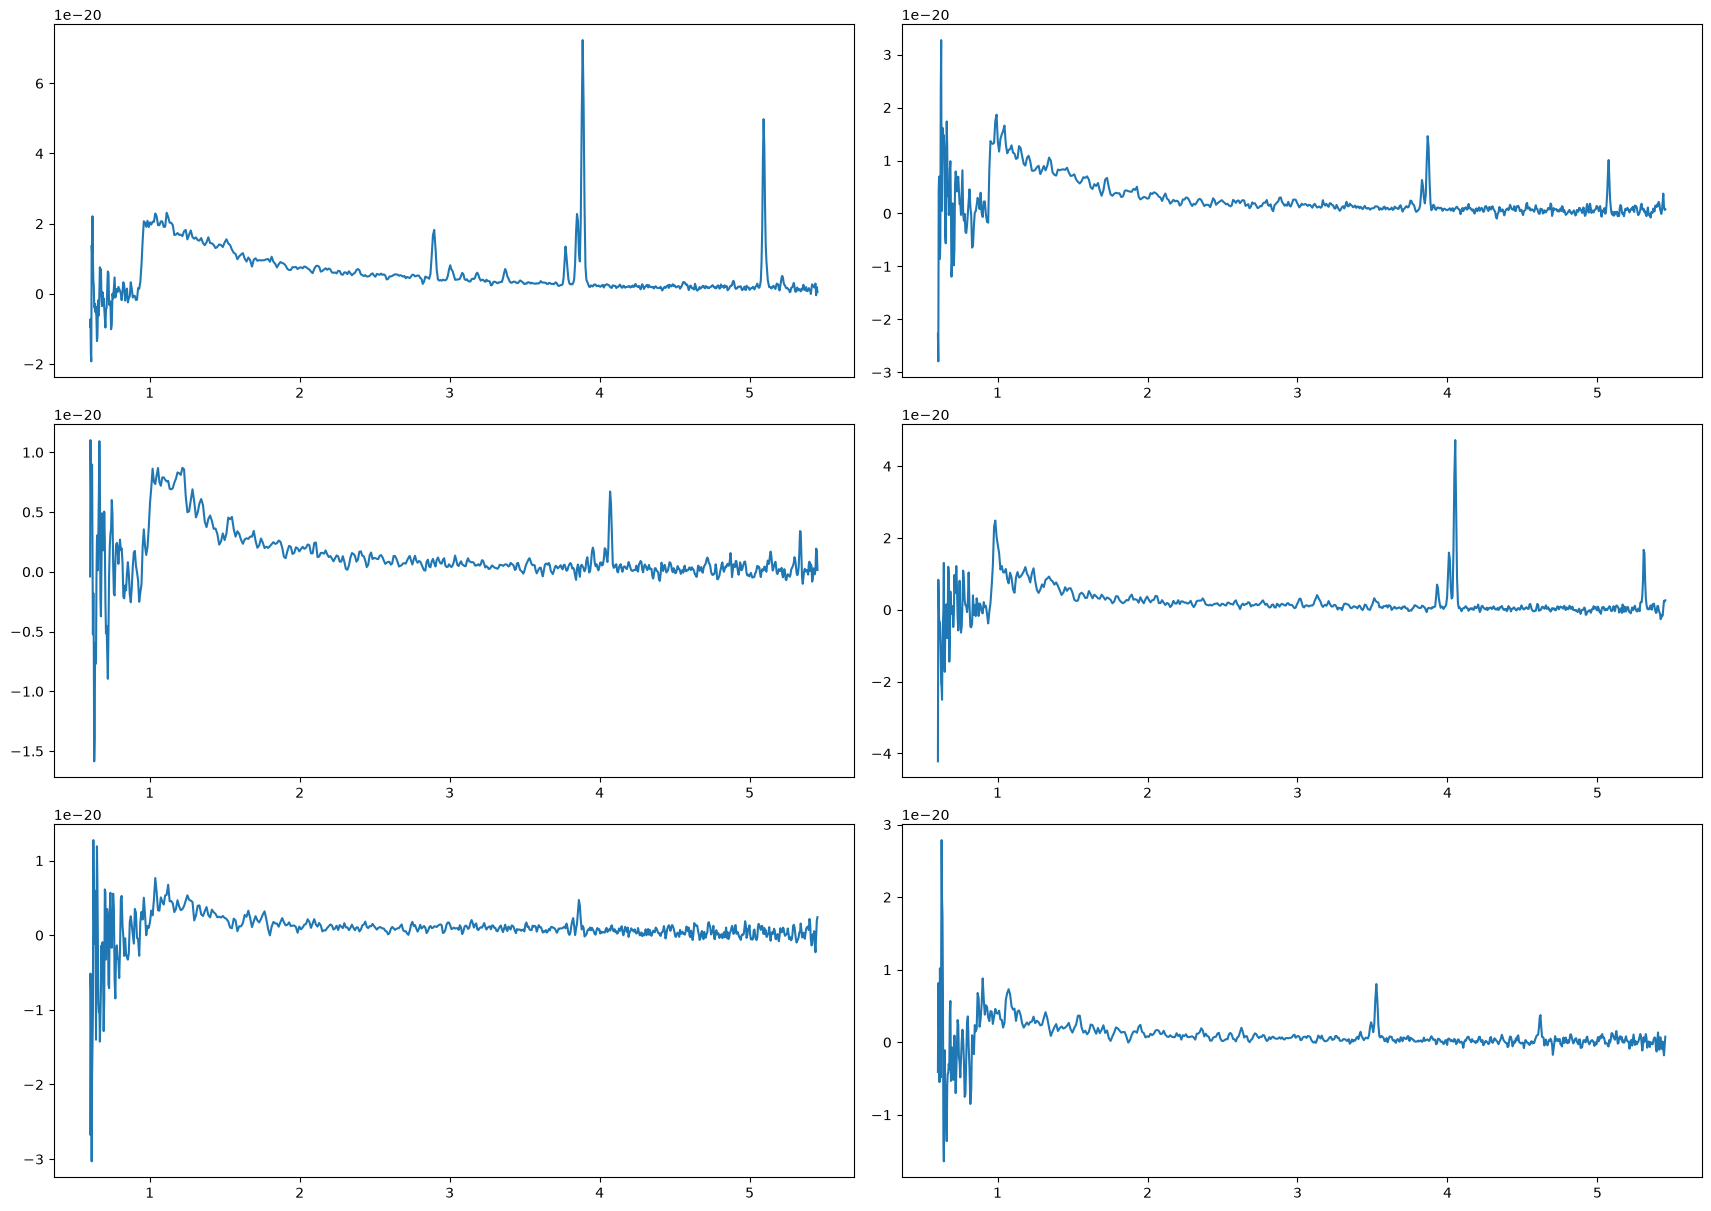

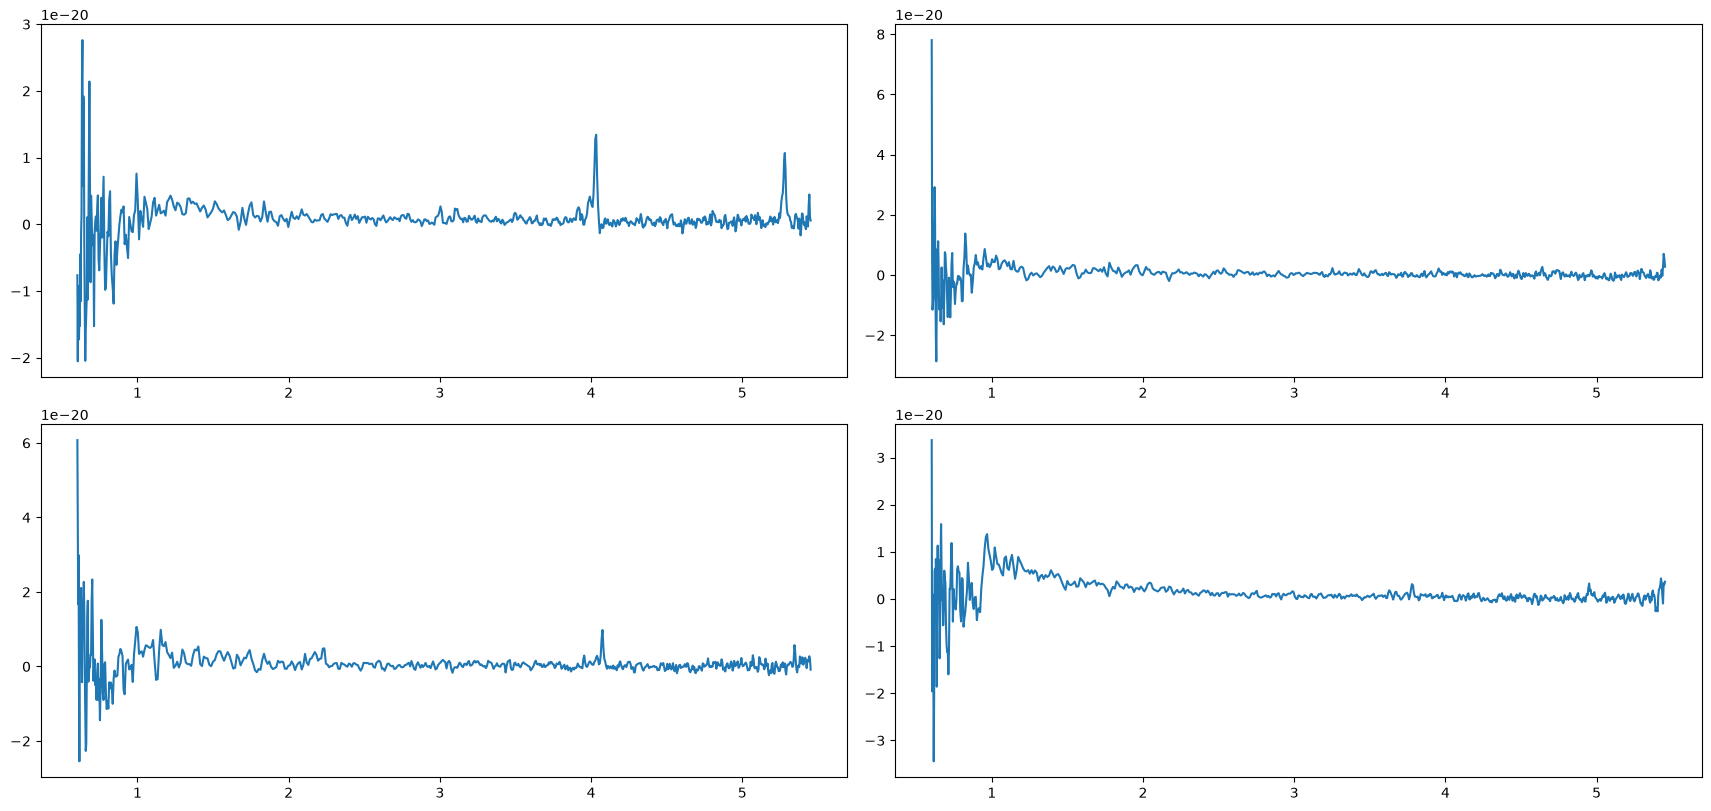

In [ ]:
path1 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1009077_clear-prism_v1.0_x1d.fits'
path2 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1022943_clear-prism_v1.0_x1d.fits'
path3 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits'
path4 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1032447_clear-prism_v1.0_x1d.fits'
path5 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1012359_clear-prism_v1.0_x1d.fits'
path6 = '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1050010_clear-prism_v1.0_x1d.fits'

data1 = Table.read(path1)
wv1 = data1['WAVELENGTH']
fx1 = data1['FLUX']
data2 = Table.read(path2)
wv2 = data2['WAVELENGTH']
fx2 = data2['FLUX']
data3 = Table.read(path3)
wv3 = data3['WAVELENGTH']
fx3 = data3['FLUX']
data4 = Table.read(path4)
wv4 = data4['WAVELENGTH']
fx4 = data4['FLUX']
data5 = Table.read(path5)
wv5 = data5['WAVELENGTH']
fx5 = data5['FLUX']
data6 = Table.read(path6)
wv6 = data6['WAVELENGTH']
fx6 = data6['FLUX']


fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(17, 12), layout="constrained")
axs[0,0].plot(wv1,fx1)
axs[0,1].plot(wv2,fx2)
axs[1,0].plot(wv3,fx3)
axs[1,1].plot(wv4,fx4)
axs[2,0].plot(wv5,fx5)
axs[2,1].plot(wv6,fx6)

path1o = '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1034762_clear-prism_v1.0_x1d.fits'
path2o = '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1037621_clear-prism_v1.0_x1d.fits'
path3o = '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1066585_clear-prism_v1.0_x1d.fits'
path4o = '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1071983_clear-prism_v1.0_x1d.fits'

data1o = Table.read(path1o)
wv1o = data1o['WAVELENGTH']
fx1o = data1o['FLUX']
data2o = Table.read(path2o)
wv2o = data2o['WAVELENGTH']
fx2o = data2o['FLUX']
data3o = Table.read(path3o)
wv3o = data3o['WAVELENGTH']
fx3o = data3o['FLUX']
data4o = Table.read(path4o)
wv4o = data4o['WAVELENGTH']
fx4o = data4o['FLUX']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(17, 8), layout="constrained")
axs[0,0].plot(wv1o,fx1o)
axs[0,1].plot(wv2o,fx2o)
axs[1,0].plot(wv3o,fx3o)
axs[1,1].plot(wv4o,fx4o)

In [18]:
'''
for i in range(len(jades_data)):
    print(jades_data[i]['ID','RA','DEC'],redshift[i]['ID','z_a'])
'''
ids_index = [18404, 8026, 14657, 28985, 16277, 6029, 41455, 20679, 39476, 19163]
jades_zphot = []
for id in ids_index:  
    jades_zphot.append(np.round(redshift[id]['z_a'],2))
print(jades_zphot)

[np.float32(7.19), np.float32(7.15), np.float32(6.82), np.float32(6.1), np.float32(7.55), np.float32(6.91), np.float32(6.6), np.float32(6.08), np.float32(7.01), np.float32(7.27)]


In [19]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = jades_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 6
params['Z_MAX'] = 12
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'JADES_north_45k_fit_1'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 181144
F070W_KRON F070W_KRON_ei (362): jwst_nircam_f070w
F090W_KRON F090W_KRON_ei (363): jwst_nircam_f090w
F105W_KRON F105W_KRON_ei (202): hst/wfc3/IR/f105w.dat
F115W_KRON F115W_KRON_ei (364): jwst_nircam_f115w
F125W_KRON F125W_KRON_ei (203): hst/wfc3/IR/f125w.dat
F140W_KRON F140W_KRON_ei (204): hst/wfc3/IR/f140w.dat
F150W_KRON F150W_KRON_ei (365): jwst_nircam_f150w
F160W_KRON F160W_KRON_ei (205): hst/wfc3/IR/f160w.dat
F162M_KRON F162M_KRON_ei (369): jwst_nircam_f162m
F182M_KRON F182M_KRON_ei (370): jwst_nircam_f182m
F200W_KRON F200W_KRON_ei (366): jwst_nircam_f200w
F210M_KRON F210M_KRON_ei (371): jwst_nircam_f210m
F277W_KRON F277W_KRON_ei (375): jwst_nircam_f277w
F300M_KRON F300M_KRON_ei (380): jwst_nircam_f300m
F335M_KRON F335M_KRON_e

Set sys_err = 0.03 (positive=True)
Template grid: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param (this may take some time)


100%|██████████| 6/6 [00:13<00:00,  2.25s/it]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 14.379 s


62it [00:03, 17.95it/s]

Fitting program initialized successfully!


In [20]:
ez.set_sys_err(positive=True) 

chunk_size = 50000

total_obj = 0
# 2. Fit the 8<z objects
print('Fitting catalog in chunks...')
# total objects: 87345
# split into chunks
for i in range(0, 304366, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = (6 <= redshift[i : i + chunk_size]['z_a']) & (redshift[i : i + chunk_size]['z_a'] <=13)
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  4968
total=  4968


100%|██████████| 62/62 [00:02<00:00, 26.87it/s]


Compute best fits
fit_best: 0.6 s (n_proc=1,  NOBJ=4412)
Fit 3.4 s (n_proc=16, NOBJ=4968)
Fitting chunk 2...
ct=  6853
total=  11821


 68%|██████▊   | 42/62 [00:02<00:00, 22.46it/s]/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:1684: RuntimeWarning: overflow encountered in cast
  self.fit_coeffs[idx_fit,iz,:] = coeffs
100%|██████████| 62/62 [00:03<00:00, 20.14it/s]


Compute best fits
fit_best: 1.3 s (n_proc=1,  NOBJ=10446)
Fit 5.0 s (n_proc=16, NOBJ=6853)
Fitting chunk 3...
ct=  5231
total=  17052


...

Compute best fits
fit_best: 2.5 s (n_proc=1,  NOBJ=19658)
Fit 3.2 s (n_proc=16, NOBJ=0)
Fitting chunk 6...
ct=  0
total=  23108


100%|██████████| 62/62 [00:00<00:00, 40926.48it/s]


Compute best fits
fit_best: 2.5 s (n_proc=1,  NOBJ=19658)
Fit 3.3 s (n_proc=16, NOBJ=0)
Fitting chunk 7...
ct=  0
total=  23108


100%|██████████| 62/62 [00:00<00:00, 34821.48it/s]


Compute best fits
fit_best: 2.5 s (n_proc=1,  NOBJ=19658)
Fit 3.2 s (n_proc=16, NOBJ=0)
Catalog fitted successfully!


In [21]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 12.6 s (n_proc=1,  NOBJ=19658)


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4014: RuntimeWarning: invalid value encountered in divide
  pzcum = (pzcum.T / pzcmax).T


Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 19658/19658 [01:40<00:00, 194.86it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4288: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T


CALLED 45K


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4323: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4653: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3539400/467368777.py:71: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}",


[18404, 8026, 14657, 28985, 16277, 6029, 41455, 20679, 39476, 19163]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


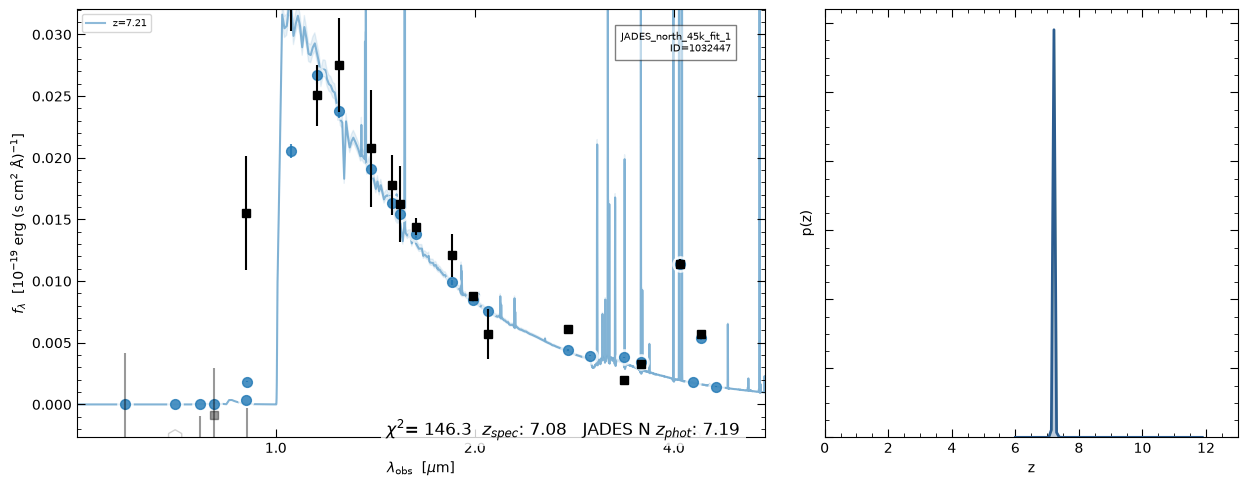

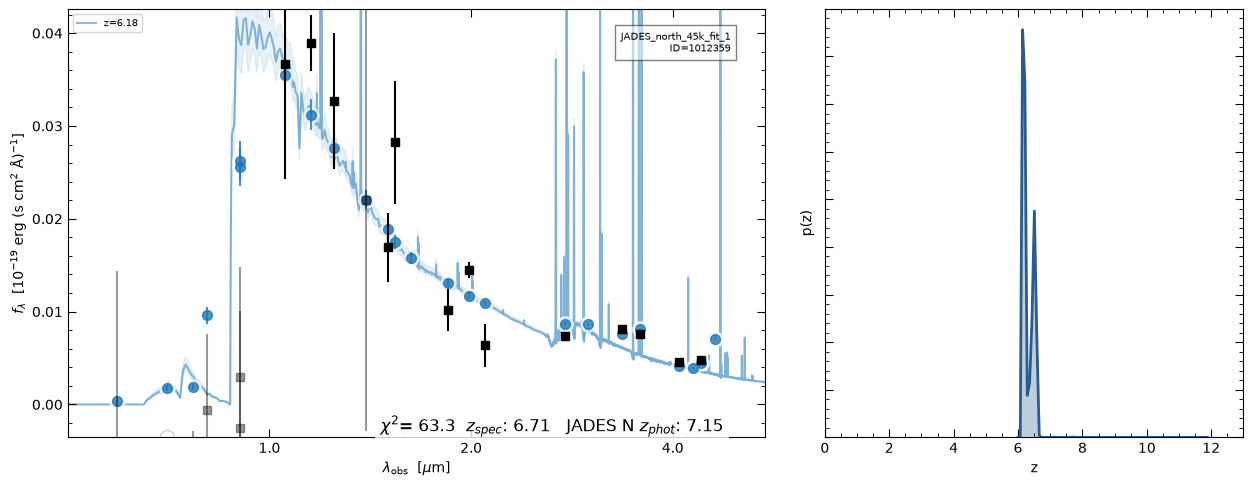

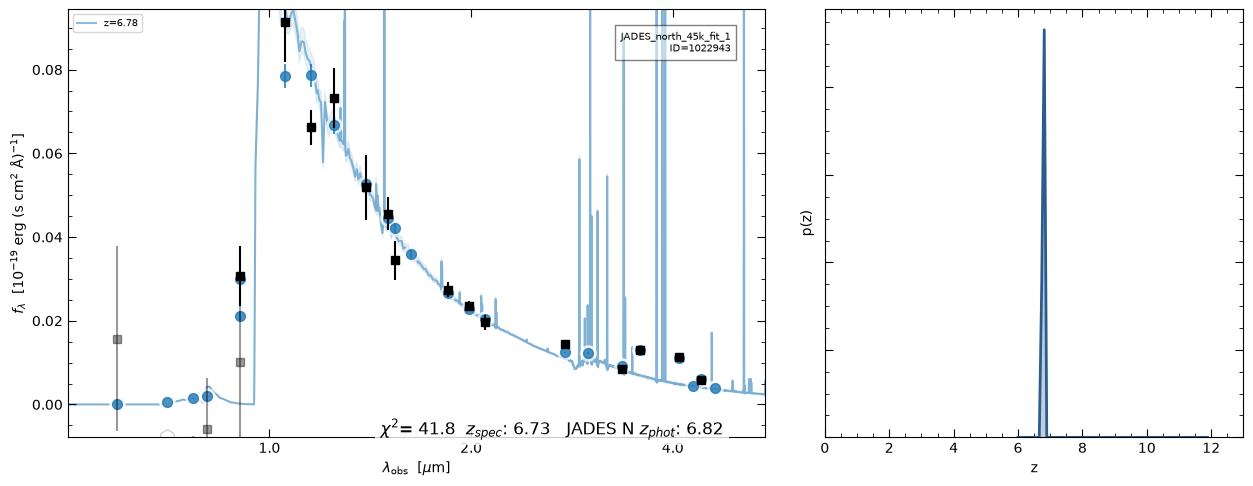

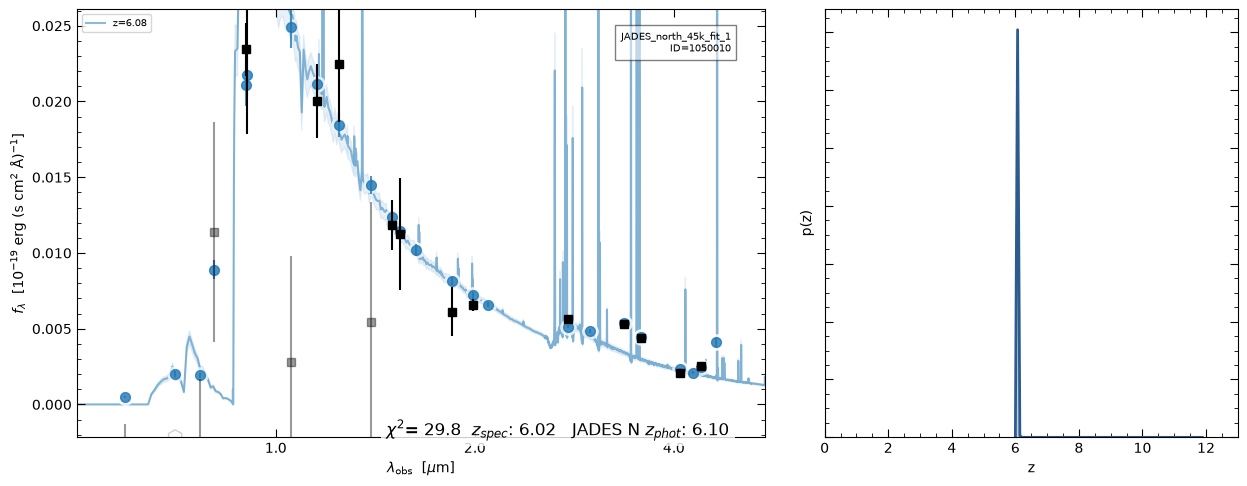

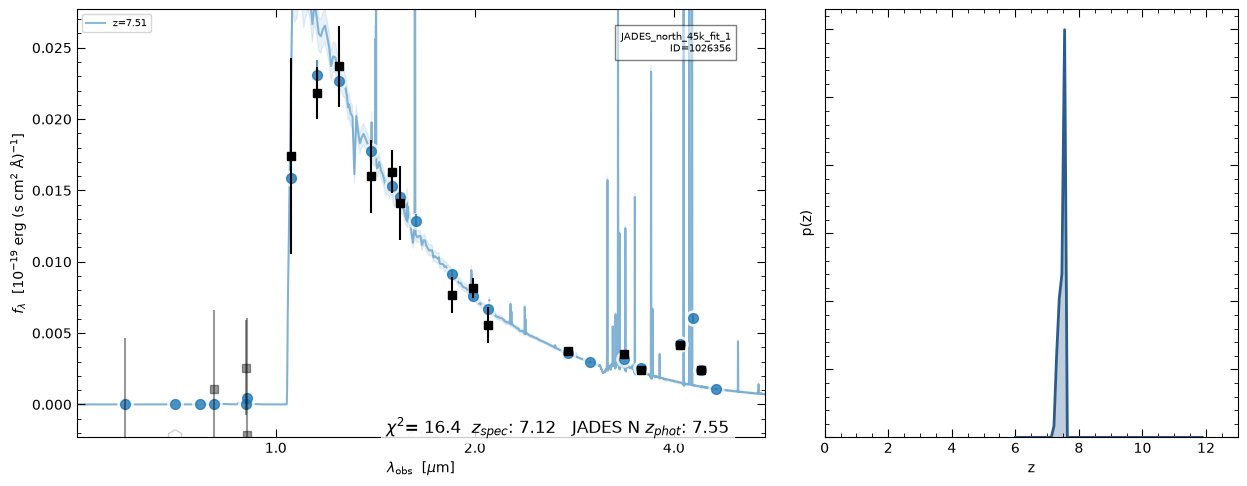

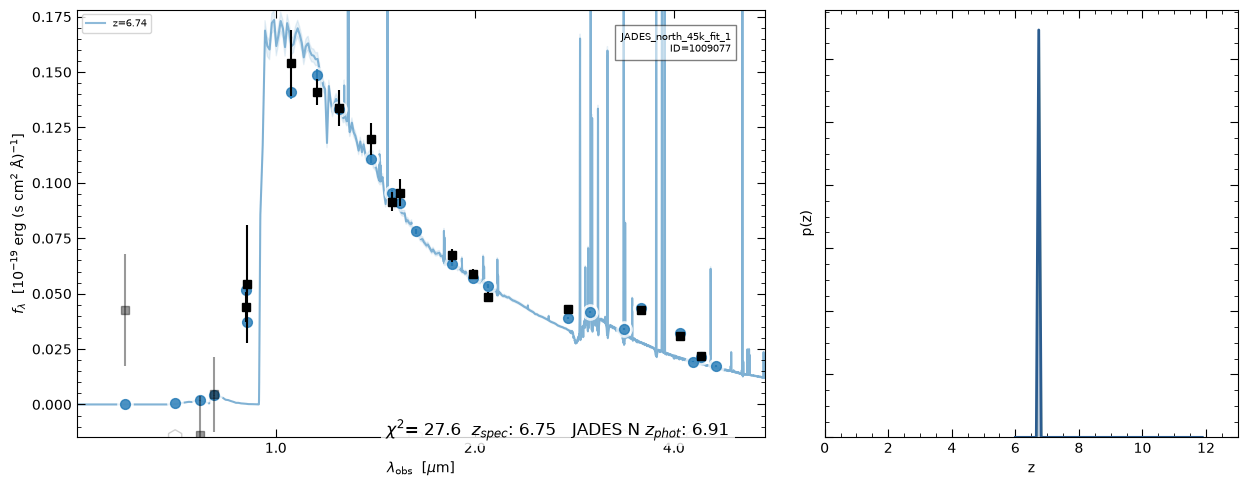

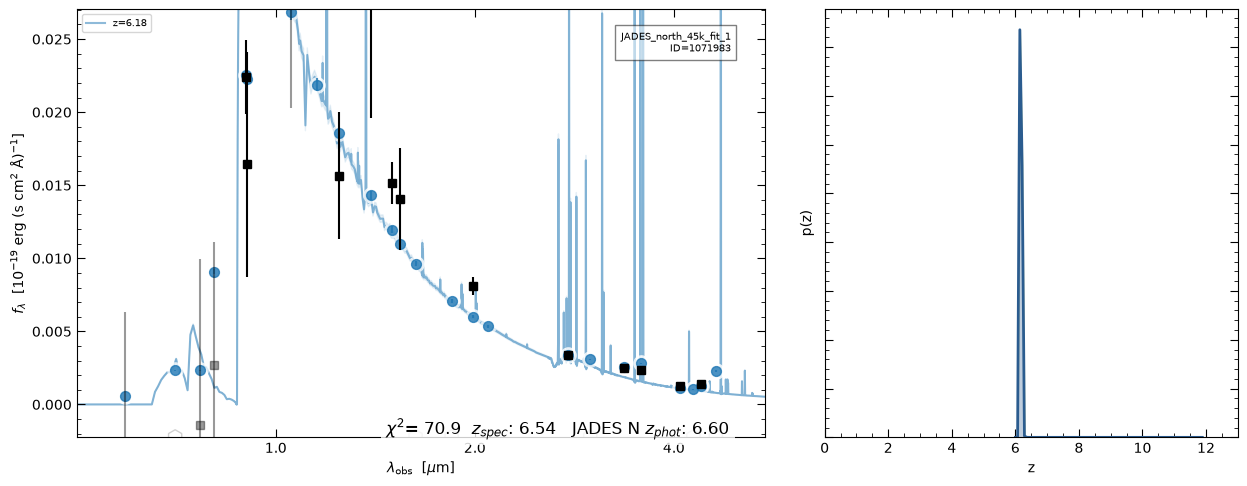

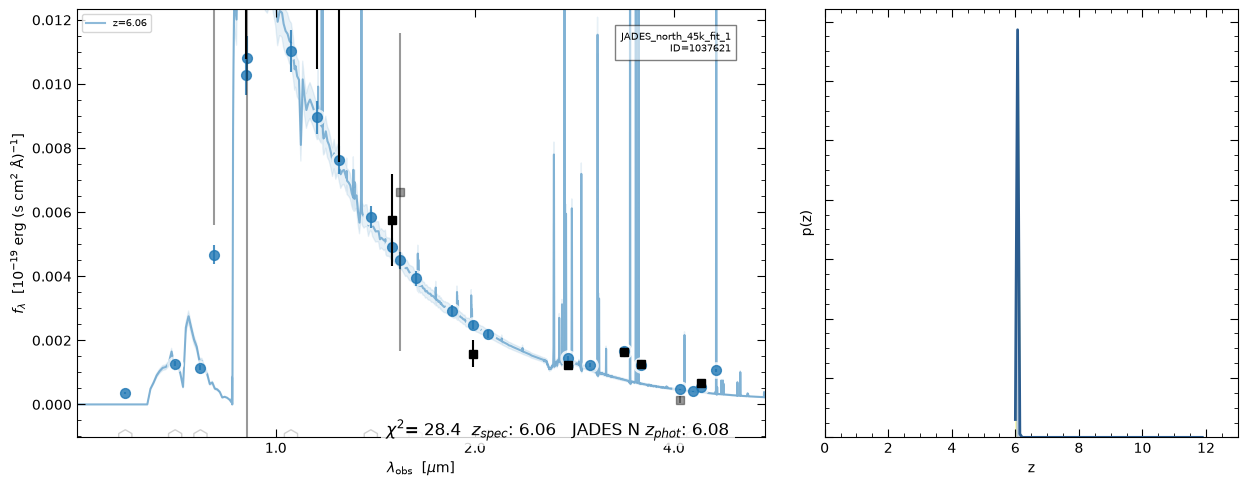

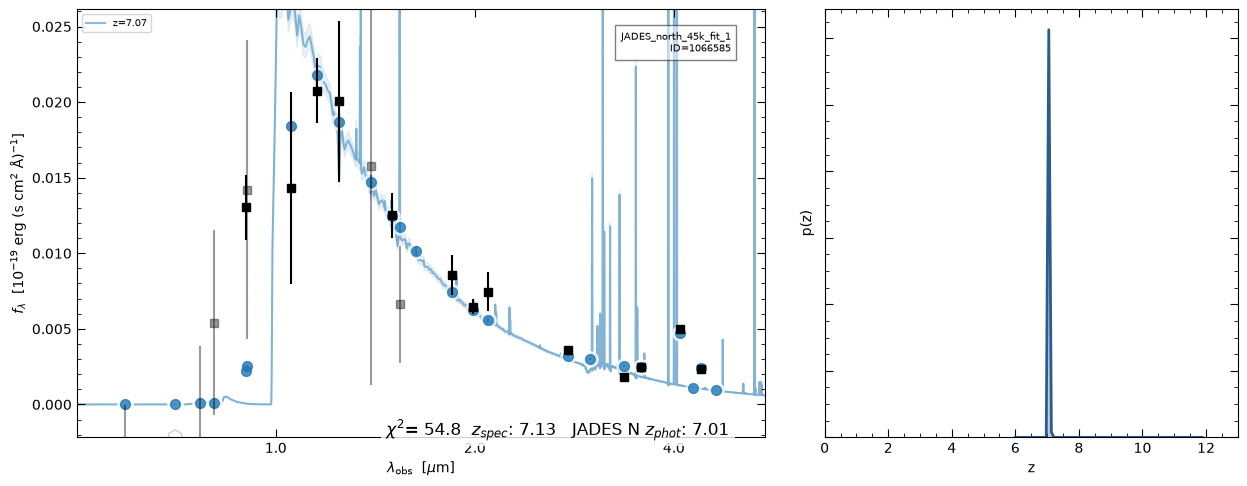

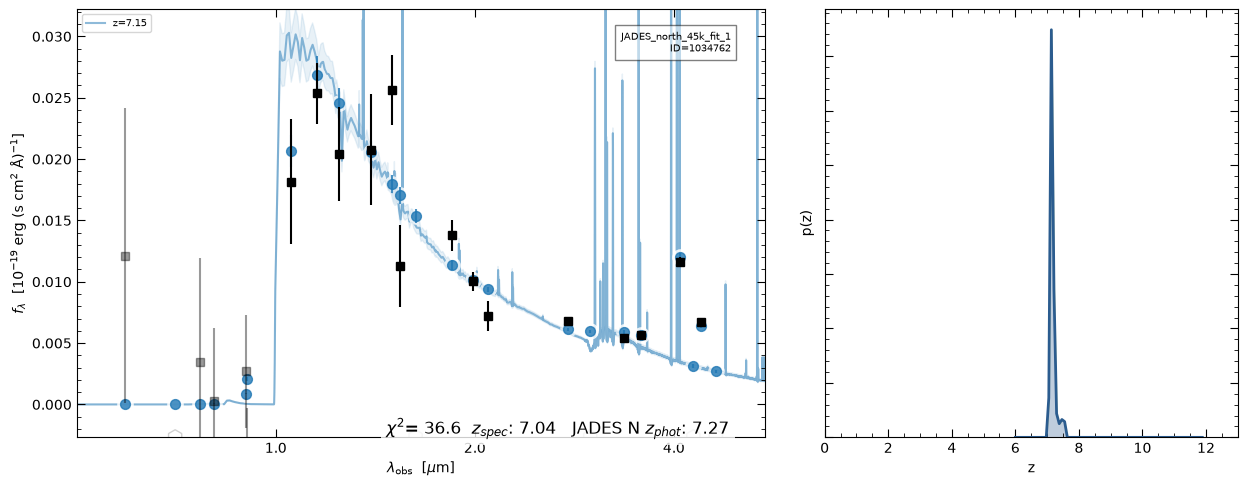

In [ ]:
from matplotlib.ticker import AutoMinorLocator

ids = ez.OBJID
mask1 = zout['z_phot'] > 0
zout_masked1 = zout[mask1]
ids_masked1 = ids[mask1]

output_path = '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/JADES_north_45k_fit_1.zout.fits'
output_data = Table.read(output_path)
#output_data_masked = output_data[mask1]

# 52480 is a little off in coords, 16224 is too
ids = [1032447,1012359,1022943,1050010,1026356,1009077,1071983,1037621,1066585,1034762]
zspec = [7.08,6.71,6.73,6.02,7.12,6.75,6.54,6.06,7.13,7.04]
#jades_zphot = [7.75,6.75,6.84,5.98,7.41,6.84,6.57,4.32,7.14,7.12]

ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

#print(output_data[ids_index]['id','z_phot','z_phot_chi2','mass'])

# pass ID where ids[i] was previously passed
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 5.5], show_components=False,
                            logpz=False, zr=[0,13])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    #fig.axes[0].set_ylim(0, 0.02)

    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 



[1032447, 1012359, 1022943, 1050010, 1026356, 1009077, 1071983, 1037621, 1066585, 1034762]


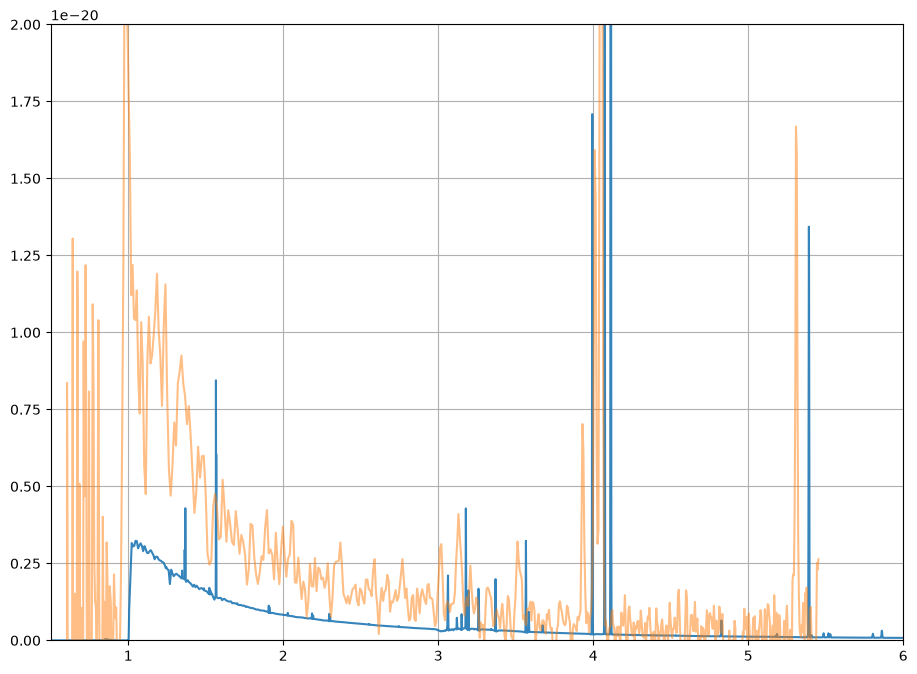

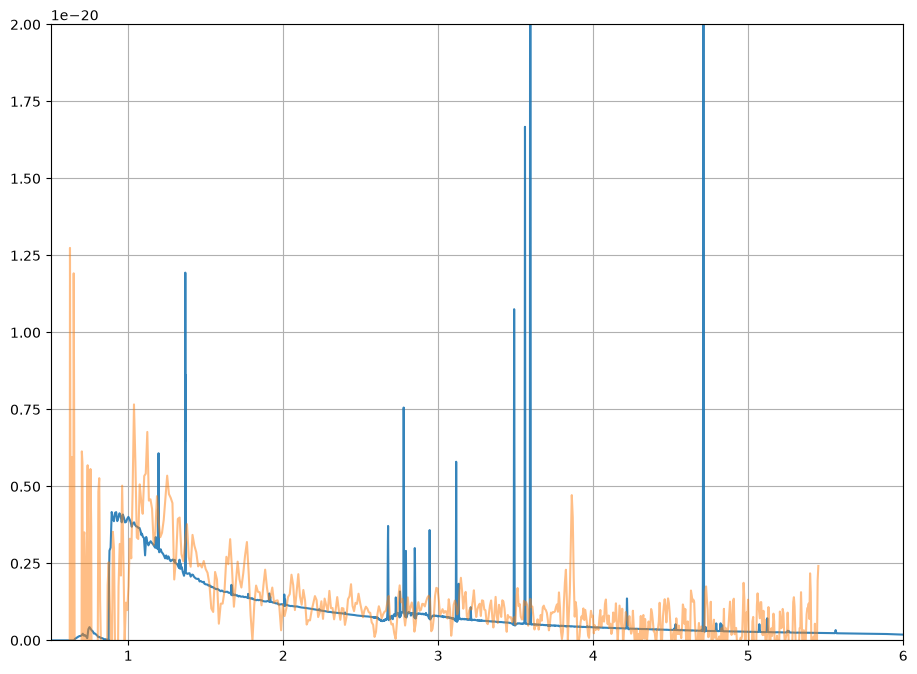

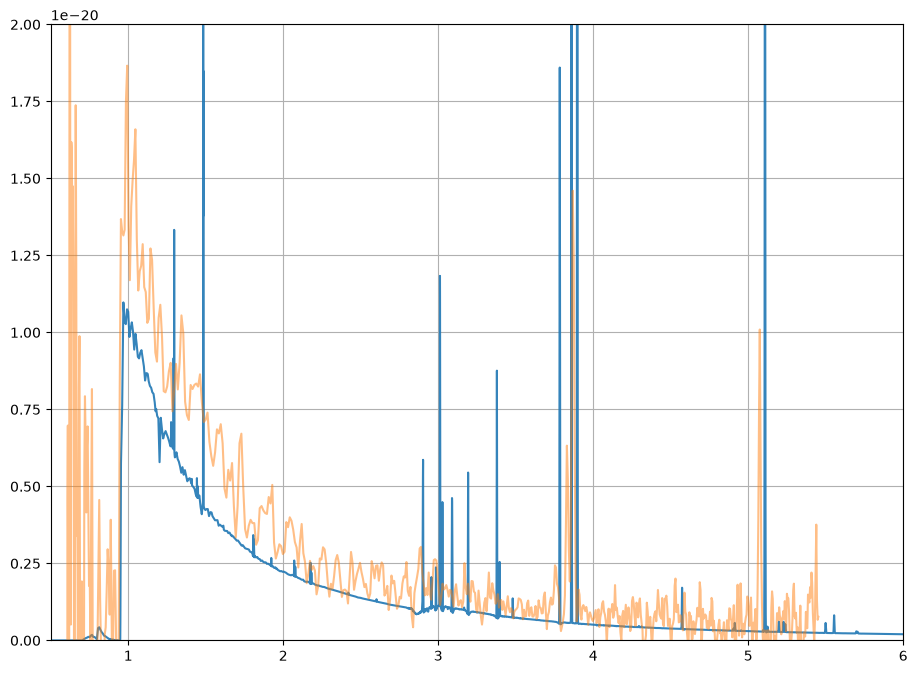

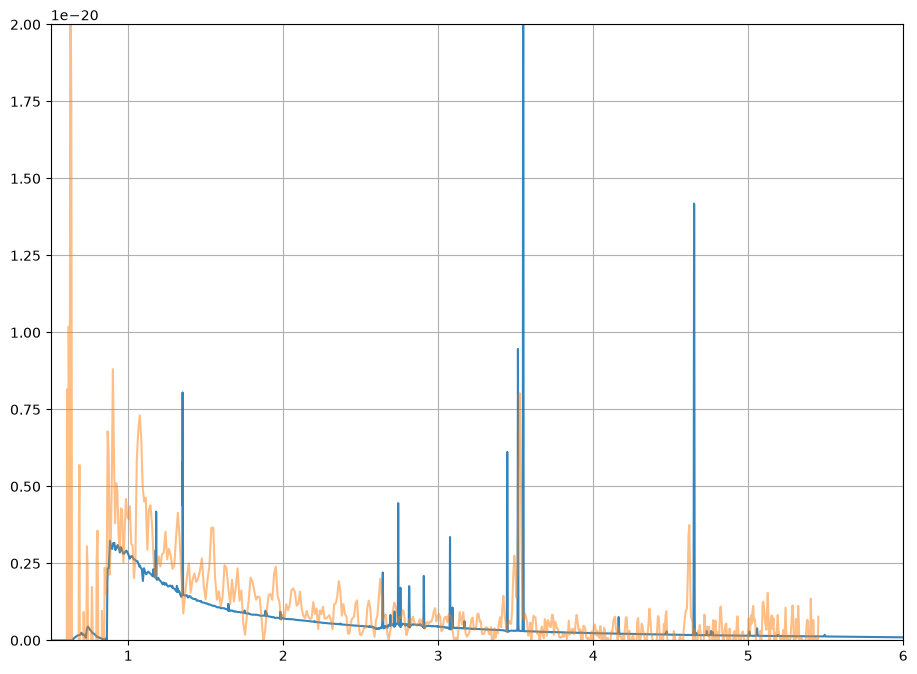

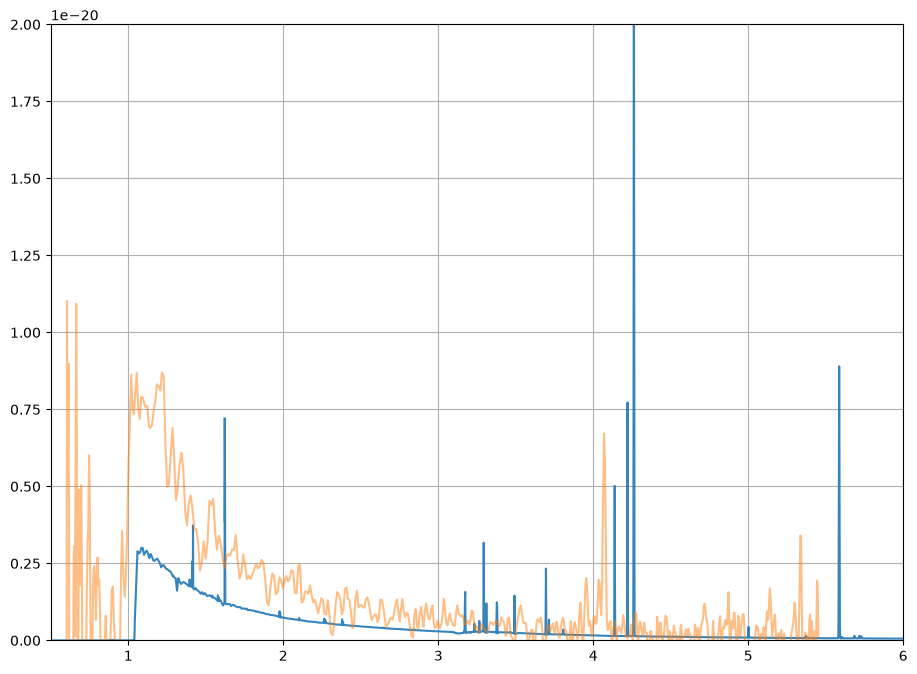

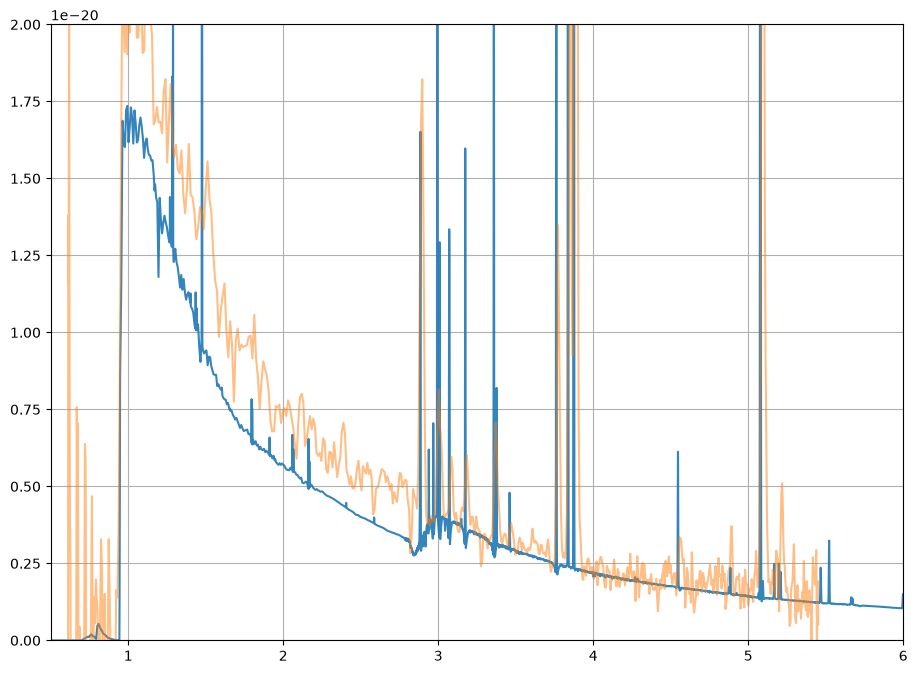

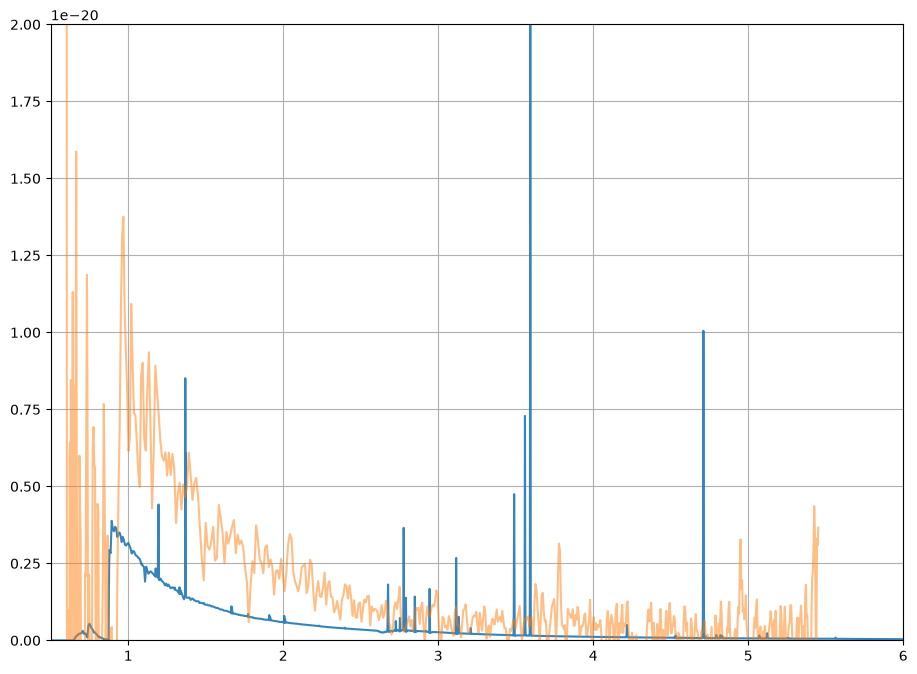

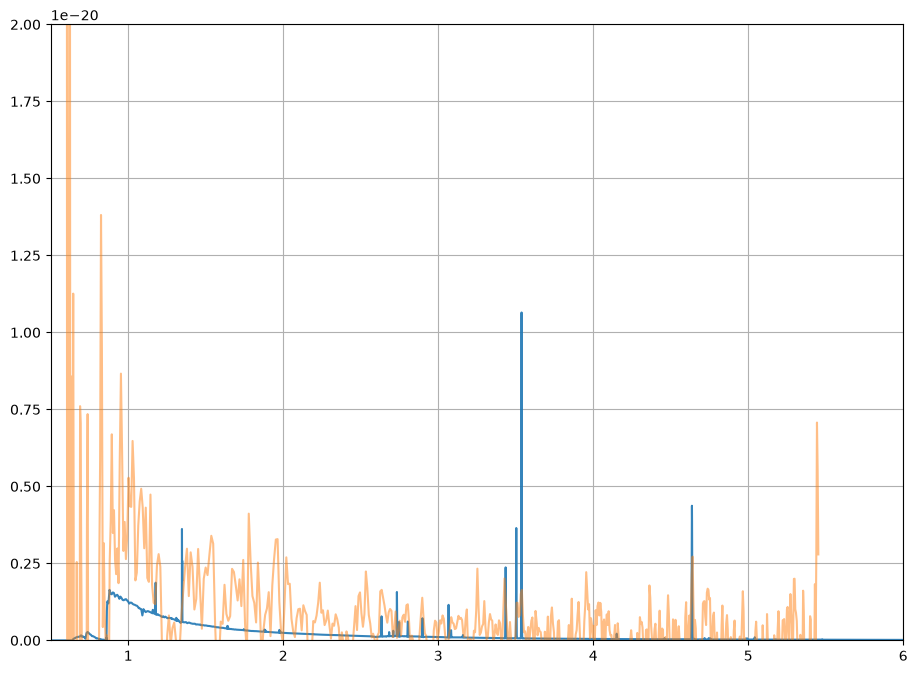

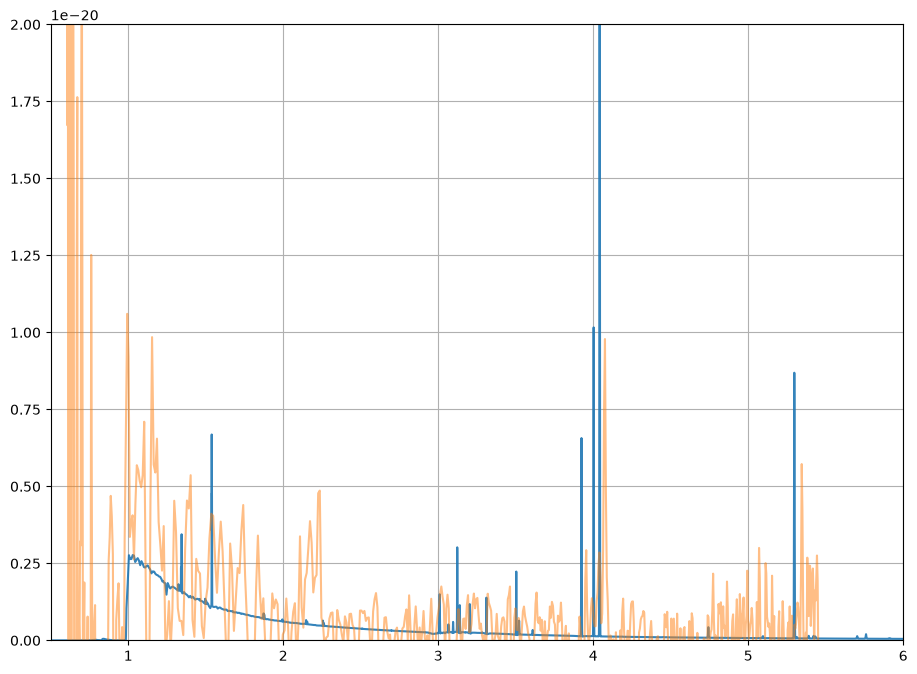

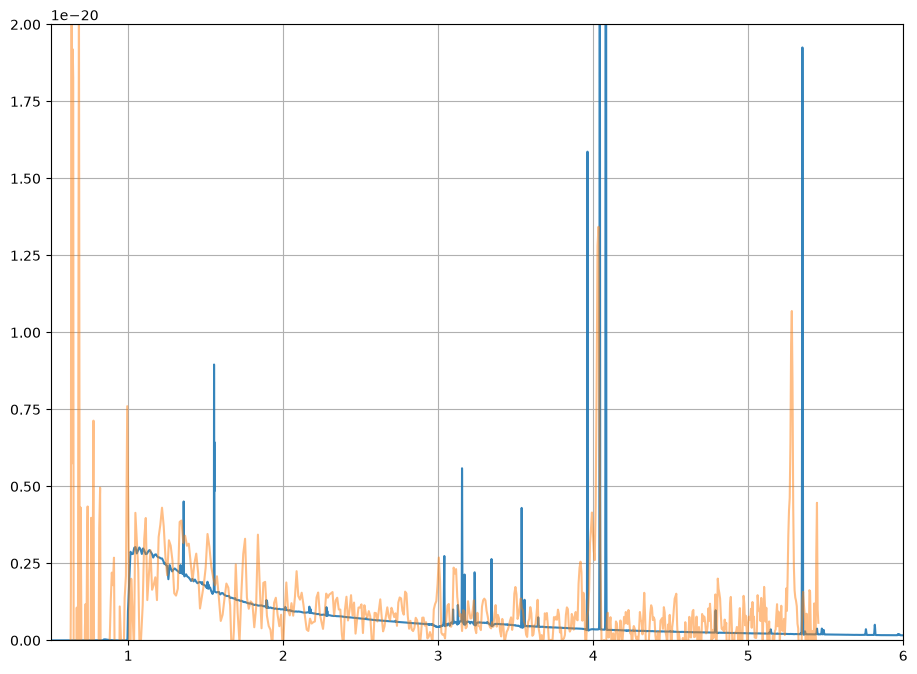

In [77]:
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')
paths = ['/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1032447_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1012359_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1022943_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1050010_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1009077_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1071983_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1037621_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1066585_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1034762_clear-prism_v1.0_x1d.fits']
print(ids)
for i in range(len(ids)):
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model = sed_data['templf'] # Best-fit template flux density
    #print(len(wavelengths))
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    flux_obs = data['FLUX']
    err_obs = data['FLUX_ERR']
    

    fig,ax = plt.subplots(figsize=(11,8))
    ax.plot(wave_model,flux_model*1e-19,alpha=.9)
    ax.grid(True)
    
    data = Table.read(paths[i])
    #print(len(data['FLUX']))
    ax.plot(data['WAVELENGTH'],data['FLUX'],alpha=.5)
    ax.set_ylim(0,2e-20)
    ax.set_xlim(0.5,6)
    #print(data['WAVELENGTH'][-1])
    #print(wavelengths[706]/10000)
    

[1032447, 1012359, 1022943, 1050010, 1026356, 1009077, 1071983, 1037621, 1066585, 1034762]
--
3.0501408685979616e+41
7.99495238232574e+41
1.5834339288128587e+41
1.967238132750418e+41
1.186823244470675e+43
--
5.95551596183599e+39
inf
--


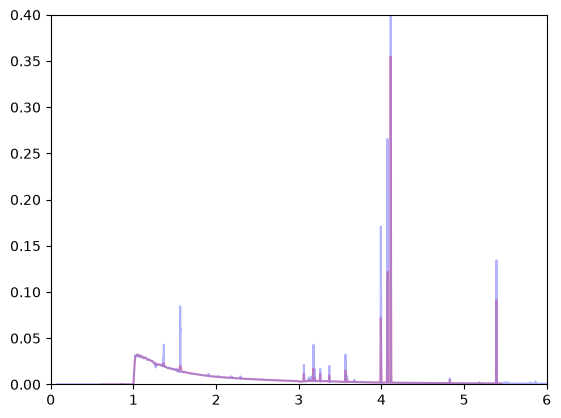

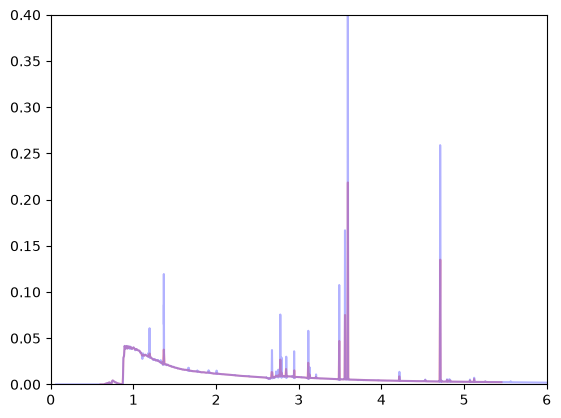

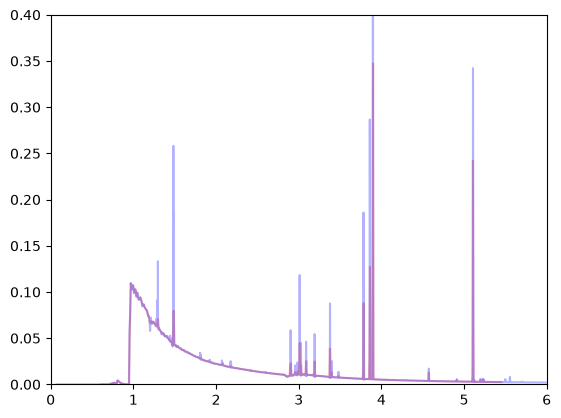

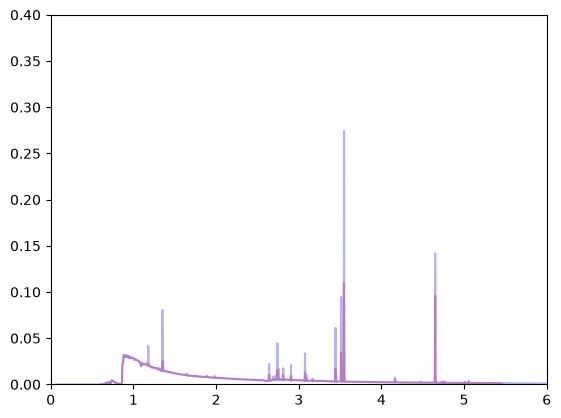

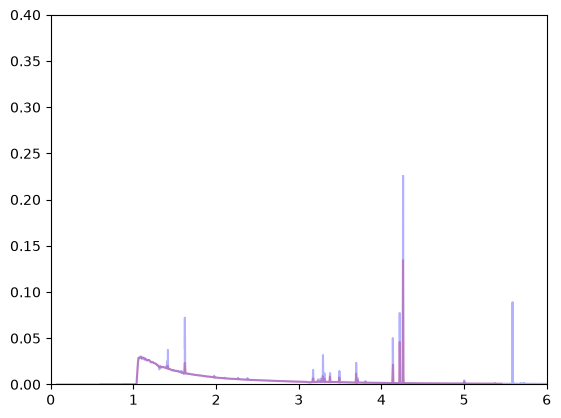

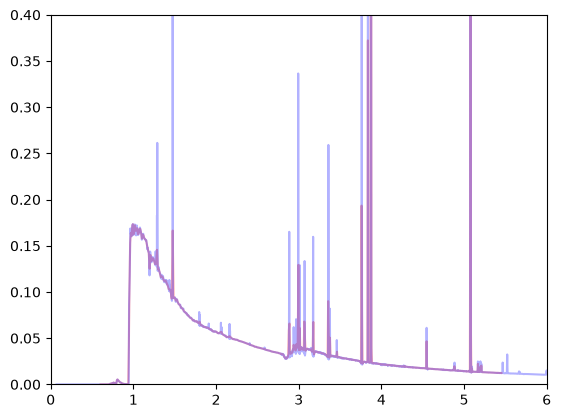

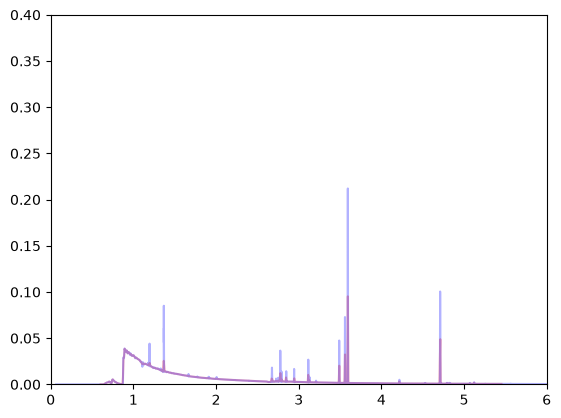

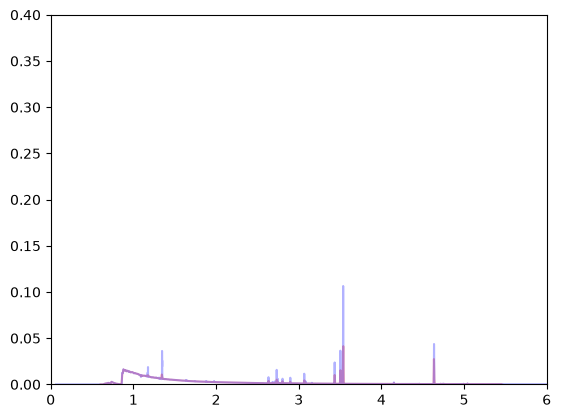

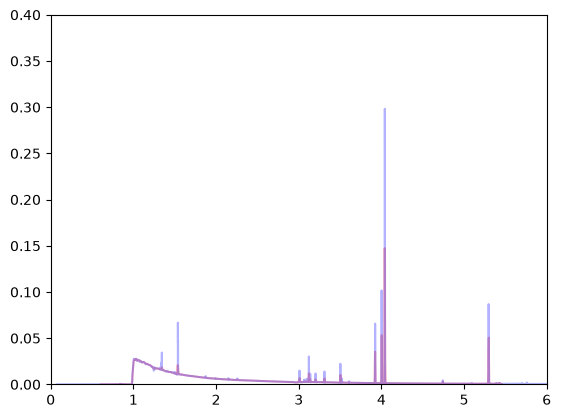

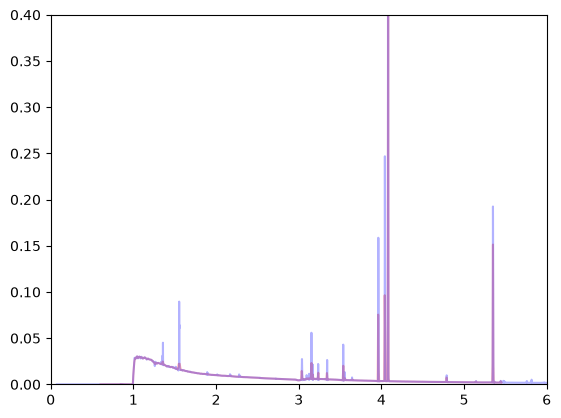

In [ ]:
from spectres import spectres
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')
paths = ['/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1032447_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1012359_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1022943_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1050010_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1009077_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1071983_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1037621_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumjwst-1066585_clear-prism_v1.0_x1d.fits',
        '/home/caltech-msanche3/data/spectra_outliers/north/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1034762_clear-prism_v1.0_x1d.fits']
print(ids)
chi_squared = []
for i in range(len(ids)):
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model = sed_data['templf'] # Best-fit template flux density
    #print(len(wavelengths))
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    flux_obs = data['FLUX']
    err_obs = data['FLUX_ERR']
    '''
    model_interp_func = interp1d(
    wave_model, 
    flux_model, 
    kind='cubic',          # 'linear' is standard; use 'cubic' for very smooth continua
    bounds_error=False,     # Avoid crashing if grids don't overlap 100%
    fill_value=np.nan       # Assign NaN to model points outside the wavelength range
    )
    flux_mod_interp = model_interp_func(wave_obs)
    '''

        # Resample the model onto the observed grid while conserving flux
    # Note: spectres handles bin-integration automatically!
    flux_model_resampled = spectres(
        wave_obs,                # Target wavelength grid
        wave_model,              # Original model wavelength grid
        flux_model,     # Smoothed model flux
        fill=np.nan,             # Fill value for out-of-bounds wavelengths
        verbose=False
    )

    #print(flux_mod_interp)
    fig,ax = plt.subplots()
    ax.plot(wave_obs,flux_model_resampled,alpha=0.3,c='r')
    ax.plot(wave_model,flux_model,alpha=.3,c='b')
    ax.set_ylim(0,.4)
    ax.set_xlim(0,6)
    
    f_obs = flux_obs
    f_mod = flux_model_resampled
    sig = err_obs

    chi2 = 0
    for i in range(706):
        res = (f_obs[i]-f_mod[i])
        chi = (res/sig[i])**2
        chi2 = chi2 + chi
    print(chi2)

    '''
    fig,ax = plt.subplots(figsize=(11,8))
    ax.plot(wavelengths,flux_density*1e-19,alpha=.9)
    ax.grid(True)
    
    data = Table.read(paths[i])
    #print(len(data['FLUX']))
    ax.plot(data['WAVELENGTH'],data['FLUX'],alpha=.5)
    ax.set_ylim(0,2e-20)
    ax.set_xlim(0.5,6)
    #print(data['WAVELENGTH'][-1])
    #print(wavelengths[706]/10000)
    '''

In [78]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
# 1. The redshift evaluation grid (1D array)
zgrid = ez.zgrid

# 2. Extract the log-likelihood array
# Shape is (NOBJ, NZ) where NOBJ is catalog size, NZ is length of zgrid
lnp = ez.lnp

# 3. Convert log-likelihood to likelihood probability distribution P(z)
# Shift by max(lnp) per object before exponentiating to avoid numerical underflow
p_z = np.exp(lnp - np.max(lnp, axis=1, keepdims=True))

# 4. Normalize P(z) so the integral over z equals 1
p_z_norm = p_z / np.trapezoid(p_z, zgrid, axis=1)[:, np.newaxis]

z_lo = []
z_hi = []
for i in range(len(ids_index)):
    if ids[i] == 159179:
        continue
    #fig,ax = plt.subplots()
    #ax.plot(zgrid,p_z_norm[ids_index][i])
    #ax.grid(True)

    cdf = cumulative_trapezoid(p_z_norm[ids_index][i], zgrid, initial=0)
    # Normalize CDF strictly to 1.0 just in case
    cdf /= cdf[-1]

    # 3. Interpolate to find the z values corresponding to the target percentiles
    z_16 = np.interp(0.16, cdf, zgrid)
    z_lo.append(zout[ids_index][i]['z_phot'] - z_16)
    #z_50 = np.interp(0.50, cdf, zgrid)  # will use z_phot instead
    z_84 = np.interp(0.84, cdf, zgrid)
    z_hi.append(z_84 - zout[ids_index][i]['z_phot'])

    #print(f"Redshift 16th percentile (z_16): {z_16:.3f}")
    #print(f"Chi^2 z_phot: {zout[ids_index][i]['z_phot']:.3f}")
    #print(f"Redshift 84th percentile (z_84): {z_84:.3f}")
    #print(f"1-sigma lower/upper bounds: z = {zout[ids_index][i]['z_phot']:.3f} +{z_84 - zout[ids_index][i]['z_phot']:.3f} -{zout[ids_index][i]['z_phot'] - z_16:.3f}")
    #print()
print(len(z_lo))


10


10
[[np.float64(0.054963063634764886), np.float64(0.03298444016772173), np.float64(0.04137494763197669), np.float64(0.062126326485099526), np.float64(0.1535121716356116), np.float64(0.052344037326842674), np.float64(0.06742531882851743), np.float64(0.04101690208029485), np.float64(0.07163168463813108), np.float64(0.06543392742490628)], [np.float64(0.05847059948071465), np.float64(0.3377357240344647), np.float64(0.07670780228545304), np.float64(0.0342396486496499), np.float64(0.07199577651010802), np.float64(0.052869986298696325), np.float64(0.052781036977394), np.float64(0.05554820381436798), np.float64(0.038583111325162456), np.float64(0.10457672763074832)]]


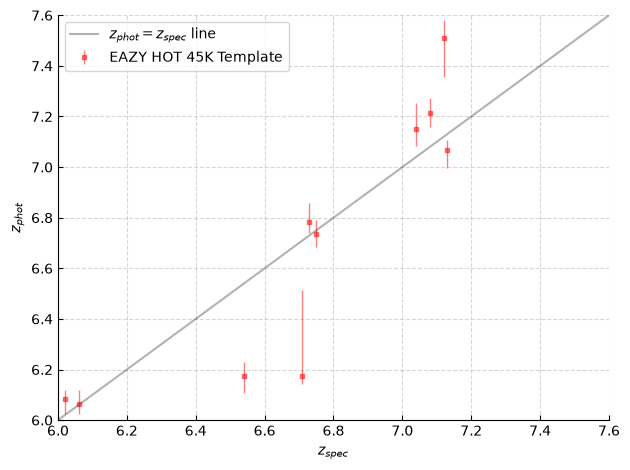

In [85]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
#find their index on the masked output table
# REMOVED OBJECT THAT DOES NOT WANT TO FIT

eazy_zphot = []
for i in range(len(ids_index)):
    eazy_zphot.append(output_data[ids_index[i]]['z_phot'])
print(len(eazy_zphot))

err = [z_lo,z_hi]
print(err)
#print(eazy_zphot)

fig,ax = plt.subplots()
x = np.linspace(6,13,10)
y = np.linspace(6,13,10)
#ax.scatter(eazy_zphot,zspec,c='r',s=3)
plt.errorbar(zspec, eazy_zphot, yerr=err, fmt='s',c='r',ms=3,elinewidth=1,alpha=0.5)
#ax.scatter(zspec,ceers_zphot,c='b',s=3)
#ax.scatter(zspec,ceers_zmed,c='b',s=3)
#plt.errorbar(zspec, ceers_zmed, yerr=ceers_err, fmt='s',c='b',ms=3,elinewidth=1,alpha=0.5)
ax.plot(x,y,alpha=0.3,c='k')
ax.set_ylim(6,7.6)
ax.set_xlim(6,7.6)
ax.set_xlabel(r'$z_{spec}$')
ax.set_ylabel(r'$z_{phot}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend([r'$z_{phot} = z_{spec}$ line',"EAZY HOT 45K Template"])
plt.tight_layout()

Average CEERS Templates z_phot absolute error: nan
Average EAZY HOT 45K Templates z_phot absolute error: 2.212e-02
10
10


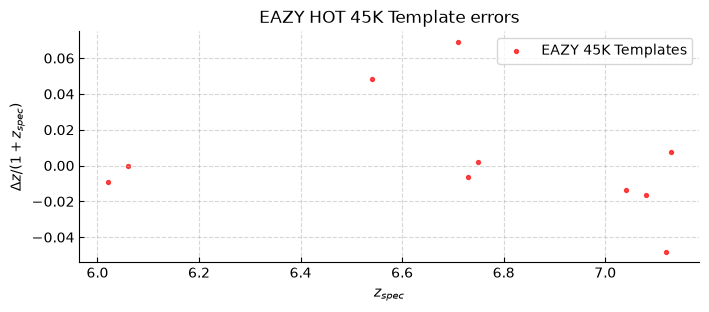

In [80]:
ceers_err = []
eazy_err = []

for i in range(len(zspec)):
    #ceers_err.append((zspec[i]-ceers_zphot[i])/(1+zspec[i]))
    #ceers_err.append((zspec[i]-ceers_zmed[i])/(1+zspec[i]))
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))
#print(eazy_err)
#print(ceers_err)
'''
ez_ct = 0
ceers_ct = 0
for i in range(13):
    if eazy_err[i] > 0.15:
        ez_ct +=1
    if ceers_err > 0.15:
        ceers_ct += 1
print(ez_ct)
print(ceers_ct)
'''
print(f"Average CEERS Templates z_phot absolute error: {np.mean(np.abs(ceers_err)):.3e}")
print(f"Average EAZY HOT 45K Templates z_phot absolute error: {np.mean(np.abs(eazy_err)):.3e}")
print(len(zspec))
print(len(eazy_err))

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='r',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("EAZY HOT 45K Template errors")
#ax.scatter(zspec,ceers_err,alpha=0.7,c='b',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
#ax.set_title("CEERS Template errors")
ax.legend(["EAZY 45K Templates"])



10


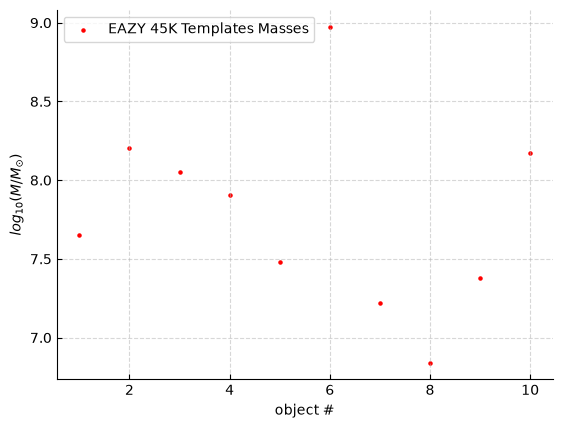

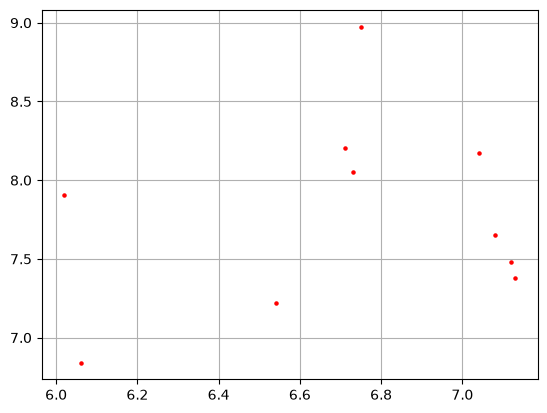

In [82]:
eazy_mass = []
x = np.linspace(1,10,10)
for id in ids_index:
    #print(f'eazy mass:',np.log10(output_data[id]['mass']))
    eazy_mass.append(np.log10(output_data[id]['mass']))
    #print(f'ceers mass:',ceers_data_masked[id]['LP_MASS_BEST'],"\n")
print(len(eazy_mass))
fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='r',s=5)
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY 45K Templates Masses"])

'''
change = []
for i in range(len(eazy_mass)):
    lin_e_mass = 10**eazy_mass[i]
    change.append((lin_e_mass/lin_c_mass).item())

print(np.mean(change))
'''
fig,ax = plt.subplots()
ax.scatter(zspec,eazy_mass,c='r',s=5)
ax.grid(True)
